### Анализ удовлетворенности клиентов. Исследование комфорта при работе климатического оборудования.

# 

#### Условие задачи

Вы работаете аналитиком в международной компании, занимающейся производством и продажами климатического оборудования: систем кондиционирования и вентиляции. Руководство поставило вам задачу проанализировать полученные данные и предоставить выводы о том, в какой тип климатического оборудования стоит инвестировать больше, чтобы повысить удовлетворенность клиентов созданными условиями в зависимости от региона? И на что стоит обратить внимание при развитии бизнеса в разных регионах?

In [53]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, chi2_contingency, pearsonr, mannwhitneyu, spearmanr, ttest_ind, spearmanr, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("data/Данные по использованию климатических систем.csv", sep=";")

#### Исследование данных на качество и предобработка

 - Названия столбцов привести в соответствии с PEP8
 - Исследовать типы данных, привести данные к правильному типу, где это необходимо
 - Проверить данные на выбросы и адекватность данных. Предположить причину возникновения выбросов и обработать такие значения.
 - Проверить данные на пропуски и заполнить их при необходимости. Обосновать решение.
 - Проверить данные на явные и неявные (в категориальных столбцах) дубликаты. Обработать дубликаты.
 - Провести аналитический и графический анализ данных. Сделать выводы.

##### Приведение столбцов в соответствии с PEP8

In [54]:
def normalize_column_name(name):
    name = name.lower()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", "_", name)
    return name


df.columns = [normalize_column_name(col) for col in df.columns]
print(df.columns)

Index(['год', 'время_года', 'климат', 'город', 'страна', 'способ_охлаждения',
       'режим_при_смешанном_типе_охлаждения', 'способ_обогрева', 'возраст',
       'пол', 'ощущение_температуры', 'ощущение_температуры_bool',
       'предпочтительное_изменение_температуры',
       'ощущение_движения_воздуха_bool',
       'предпочтительное_изменение_движения_воздуха', 'оценка_комфорта',
       'утепление', 'температура_воздуха_в_помещении',
       'температура_воздуха_на_улице', 'rh', 'скорость_воздуха', 'рост', 'вес',
       'занавески', 'вентилятор', 'окно', 'двери', 'отопление',
       'среднемесячная_температура_на_улице', 'количество_рекламаций'],
      dtype='str')


##### Приведение данных к правильному типу

In [55]:
TYPE_CONVERSIONS = {
    "год": "float64",
    "возраст": "float64",
    "ощущение_температуры": "float64",
    "ощущение_температуры_bool": "bool",
    "ощущение_движения_воздуха_bool": "bool",
    "оценка_комфорта": "float64",
    "утепление": "float64",
    "температура_воздуха_в_помещении": "float64",
    "температура_воздуха_на_улице": "float64",
    "rh": "float64",
    "скорость_воздуха": "float64",
    "рост": "float64",
    "вес": "float64",
    "занавески": "bool",
    "вентилятор": "bool",
    "окно": "bool",
    "двери": "bool",
    "отопление": "bool",
    "среднемесячная_температура_на_улице": "float64",
    "количество_рекламаций": "float64",
}
for col, dtype in TYPE_CONVERSIONS.items():
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(dtype)
print(df.dtypes)

год                                            float64
время_года                                         str
климат                                             str
город                                              str
страна                                             str
способ_охлаждения                                  str
режим_при_смешанном_типе_охлаждения                str
способ_обогрева                                    str
возраст                                        float64
пол                                                str
ощущение_температуры                           float64
ощущение_температуры_bool                         bool
предпочтительное_изменение_температуры             str
ощущение_движения_воздуха_bool                    bool
предпочтительное_изменение_движения_воздуха        str
оценка_комфорта                                float64
утепление                                      float64
температура_воздуха_в_помещении                float64
температур

##### Проверка данных на выбросы и адекватность

In [56]:
# Деление по типу фактора на количественные и категориальные
numeric_cols = ["возраст", "ощущение_температуры", "оценка_комфорта", "утепление",
                "температура_воздуха_в_помещении", "температура_воздуха_на_улице",
                "rh", "скорость_воздуха", "среднемесячная_температура_на_улице",
                "количество_рекламаций", "рост", "вес",]
nominal_cols = [i for i in df.columns if i not in numeric_cols]
print(numeric_cols)
print(nominal_cols)


['возраст', 'ощущение_температуры', 'оценка_комфорта', 'утепление', 'температура_воздуха_в_помещении', 'температура_воздуха_на_улице', 'rh', 'скорость_воздуха', 'среднемесячная_температура_на_улице', 'количество_рекламаций', 'рост', 'вес']
['год', 'время_года', 'климат', 'город', 'страна', 'способ_охлаждения', 'режим_при_смешанном_типе_охлаждения', 'способ_обогрева', 'пол', 'ощущение_температуры_bool', 'предпочтительное_изменение_температуры', 'ощущение_движения_воздуха_bool', 'предпочтительное_изменение_движения_воздуха', 'занавески', 'вентилятор', 'окно', 'двери', 'отопление']


In [57]:
# Проверка категориальных данных на адекватность
for i in nominal_cols:
    print(i)
    print(df[i].unique())
    print()

год
[2011. 2010. 2012.]

время_года
<StringArray>
['Лето', 'Зима', 'Весна', 'Осень']
Length: 4, dtype: str

климат
<StringArray>
[     'Cубтропический океанический',                  'Cубтроп океанич',
       'Субтропическое высокогорье',            'Жаркий полузасушливый',
      'Тропическая влажная саванна', 'Влажный субтропический муссонный']
Length: 6, dtype: str

город
<StringArray>
[     'Техас',     'Сидней',      'Шимла', 'Хайдарабад',   'Бангалор',
  'Ахмедабад',     'Ченнай',       'Дели']
Length: 8, dtype: str

страна
<StringArray>
['США', 'Австралия', 'Индия']
Length: 3, dtype: str

способ_охлаждения
<StringArray>
['Кондиционирование', 'Смешанный', 'Вентиляция']
Length: 3, dtype: str

режим_при_смешанном_типе_охлаждения
<StringArray>
[nan, 'Кондиционирование', 'Вентиляция']
Length: 3, dtype: str

способ_обогрева
<StringArray>
[nan, 'Механическое отопление']
Length: 2, dtype: str

пол
<StringArray>
[nan, 'Женский', 'Мужской']
Length: 3, dtype: str

ощущение_температуры_bool


 - В факторе климат есть ошибки в виде значения "Cубтроп океанич" - необходимо заменить на "Cубтропический океанический"
 - В факторе предпочтительное_изменение_температуры есть ошибки в виде значений "Холодн" и "Тепле" - необходимо заменить на "Холоднее" и "Теплее" соответственно

In [58]:
# Исправление ошибок в категориальных данных
df.loc[df["климат"] == "Cубтроп океанич", "климат"] = "Cубтропический океанический"
df.loc[df["предпочтительное_изменение_температуры"] == "Тепле", "предпочтительное_изменение_температуры"] = "Теплее"
df.loc[df["предпочтительное_изменение_температуры"] == "Холодн", "предпочтительное_изменение_температуры"] = "Холоднее"
print(df["климат"].unique())
print(df["предпочтительное_изменение_температуры"].unique())

<StringArray>
[     'Cубтропический океанический',       'Субтропическое высокогорье',
            'Жаркий полузасушливый',      'Тропическая влажная саванна',
 'Влажный субтропический муссонный']
Length: 5, dtype: str
<StringArray>
['Без изменений', 'Теплее', 'Холоднее']
Length: 3, dtype: str


In [59]:
# Проверка количественных данных на адекватность
for i in numeric_cols:
    print(i)
    print(f"min   {df[i].min()};   max   {df[i].max()}")
    print(f"median   {round(df[i].median(), 5)};   mean   {round(df[i].mean(), 5)}")
    print()

возраст
min   22.0;   max   65.0
median   42.0;   mean   40.63438

ощущение_температуры
min   -3.0;   max   3.0
median   0.0;   mean   0.20331

оценка_комфорта
min   1.0;   max   6.0
median   5.0;   mean   4.77209

утепление
min   0.36;   max   2.08
median   0.59;   mean   0.63459

температура_воздуха_в_помещении
min   16.2;   max   77.0
median   24.6;   mean   26.07211

температура_воздуха_на_улице
min   22.8;   max   25.9
median   24.1;   mean   24.10417

rh
min   23.8;   max   85.1
median   53.75;   mean   52.97376

скорость_воздуха
min   0.0;   max   63.83
median   0.1;   mean   0.76056

среднемесячная_температура_на_улице
min   8.5;   max   328.0
median   22.0;   mean   27.38967

количество_рекламаций
min   0.0;   max   3.0
median   0.0;   mean   0.10537

рост
min   5.23;   max   190.5
median   165.1;   mean   164.41168

вес
min   42.0;   max   110.0
median   65.0;   mean   65.47196



 - В факторе температура_воздуха_в_помещении есть выбросы сверху - наибольшее значение равно 77 
 - В факторе скорость_воздуха есть выбросы сверху - наибольшее значение равно 63.83, в то время как медиана равна 0.1
 - В факторе среднемесячная_температура_на_улице есть выбросы сверху - наибольшее значение равно 328 (ад какой-то)
 - В факторе рост выбросы снизу - наименьшее значение равно 5.23 (возможно респондент думал, что значение в футах, а не в сантиметрах)

In [60]:
# Замена выбросов на медиану
anomaly_cols = ["температура_воздуха_в_помещении", "скорость_воздуха", "среднемесячная_температура_на_улице", "рост"]
for i in anomaly_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = round(Q3 - Q1, 5)
    print(i)
    print(Q1, Q3, IQR)
    if i == "рост":
        lower_bound = round(Q1 - 3 * IQR, 5)
        print("Нижняя граница:", lower_bound)
        print("Заменено выбросов:", len(df.loc[df[i] < lower_bound]))
        df.loc[df[i] < lower_bound, i] = df[i].median()
    else:
        upper_bound = round(Q3 + 3 * IQR, 5)
        print("Верхняя граница:", upper_bound)
        print("Заменено выбросов:", len(df.loc[df[i] > upper_bound]))
        df.loc[df[i] > upper_bound, i] = df[i].median()

температура_воздуха_в_помещении
23.8 25.9 2.1
Верхняя граница: 32.2
Заменено выбросов: 24
скорость_воздуха
0.06 0.14 0.08
Верхняя граница: 0.38
Заменено выбросов: 32
среднемесячная_температура_на_улице
22.0 30.8 8.8
Верхняя граница: 57.2
Заменено выбросов: 12
рост
160.0 172.7 12.7
Нижняя граница: 121.9
Заменено выбросов: 2


In [61]:
# Также проверим на соответствие стран и городов
group_country = df.groupby("страна")
print(group_country["город"].value_counts())
# Всё правильно


страна     город     
Австралия  Сидней        198
Индия      Ченнай         51
           Ахмедабад      38
           Дели           35
           Шимла          32
           Хайдарабад     32
           Бангалор       26
США        Техас          72
Name: count, dtype: int64


##### Проверка данных на пропуски и их заполнение

In [62]:
print(df.isna().sum())

год                                              0
время_года                                       0
климат                                           0
город                                            0
страна                                           0
способ_охлаждения                                0
режим_при_смешанном_типе_охлаждения            147
способ_обогрева                                262
возраст                                         71
пол                                             72
ощущение_температуры                             0
ощущение_температуры_bool                        0
предпочтительное_изменение_температуры           0
ощущение_движения_воздуха_bool                   0
предпочтительное_изменение_движения_воздуха      0
оценка_комфорта                                269
утепление                                        0
температура_воздуха_в_помещении                  0
температура_воздуха_на_улице                   412
rh                             

Предположения по причине выбросов:
 - режим_при_смешанном_типе_охлаждения: отсутствие смешанного типа охлаждения, применялось только одно из них, но не оба
 - способ_обогрева: отсутствие нужды в обогреве
 - возраст: комплексы у респондентов и нежелание давать личную информацию 
 - пол: нежелание давать личную информацию
 - оценка_комфорта: неуверенность в оценке у респондента
 - температура_воздуха_на_улице: температура почти исключительно измерялась в помещении (почти всё пропущено)
 - рост: комплексы у респондентов и нежелание давать личную информацию
 - вес: комплексы у респондентов и нежелание давать личную информацию

In [63]:
# Я не знаю как их заполнить, поэтому пока заполнил только пол
# Модой по странам не получится, так как в Америке неизвестно ни одного пола, при чем все пропуски именно в США
df["пол"] = df["пол"].fillna("Неизвестно")

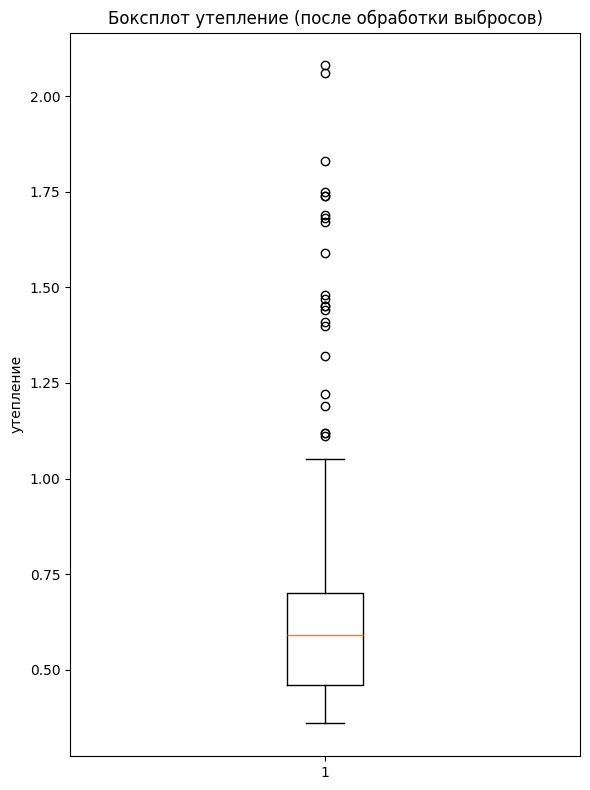

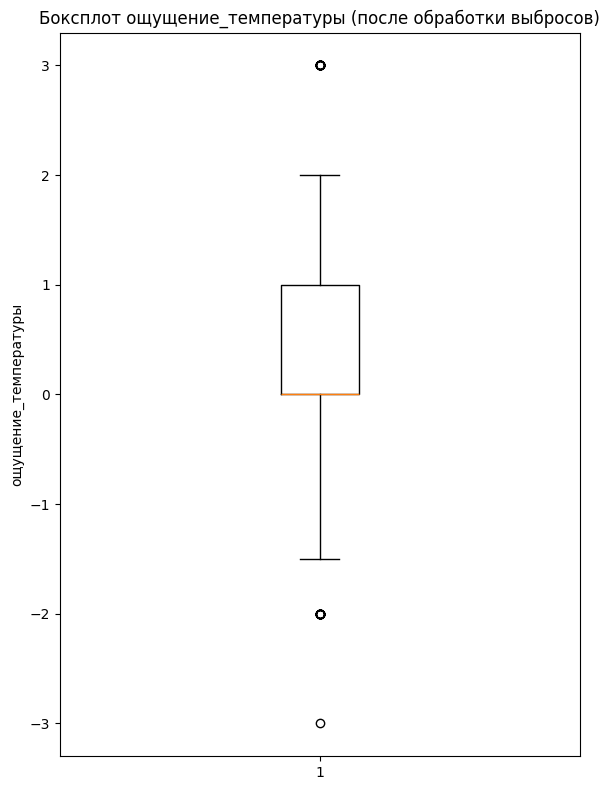

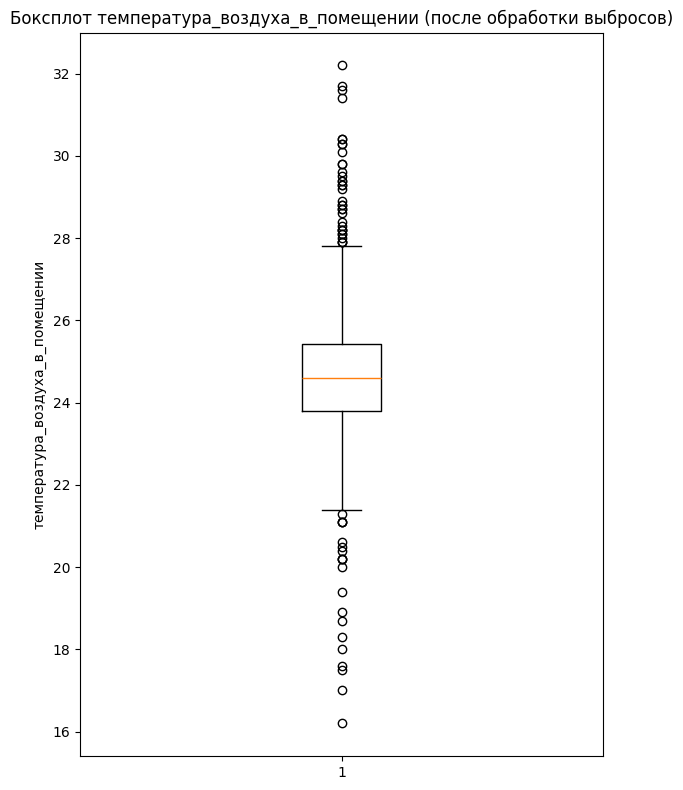

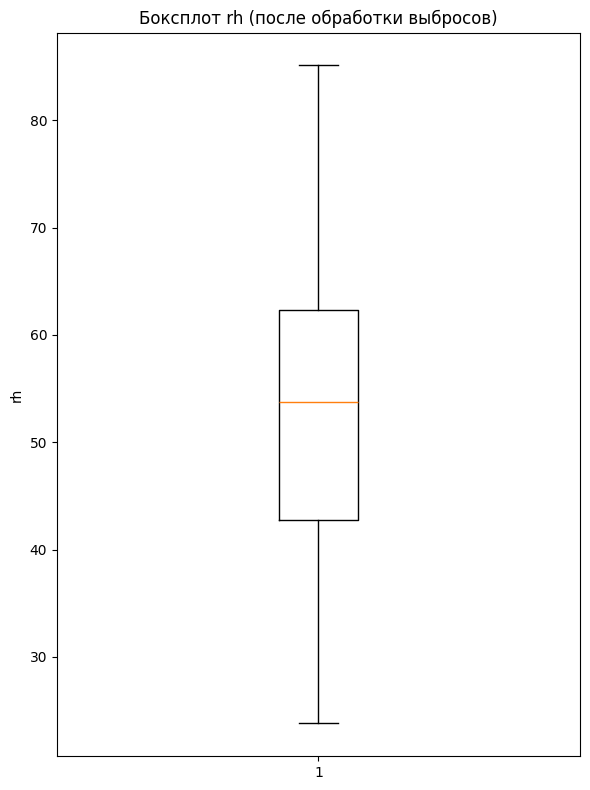

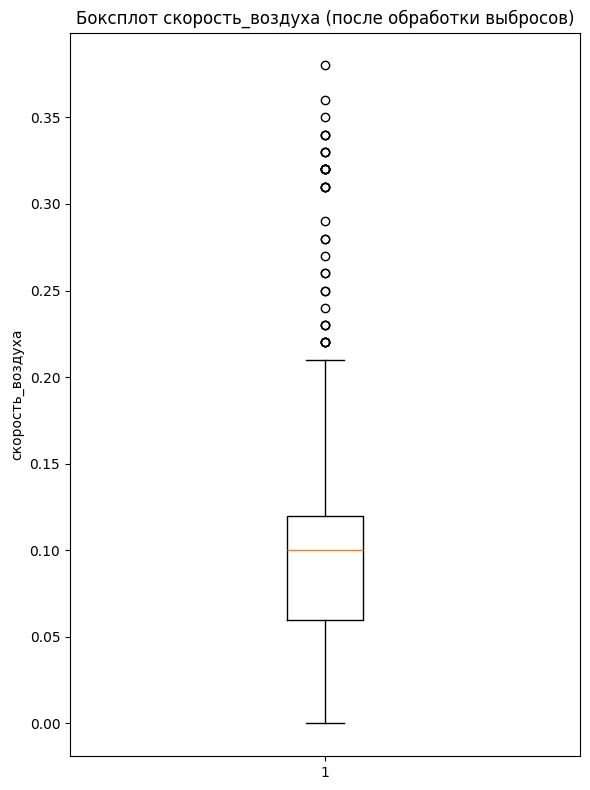

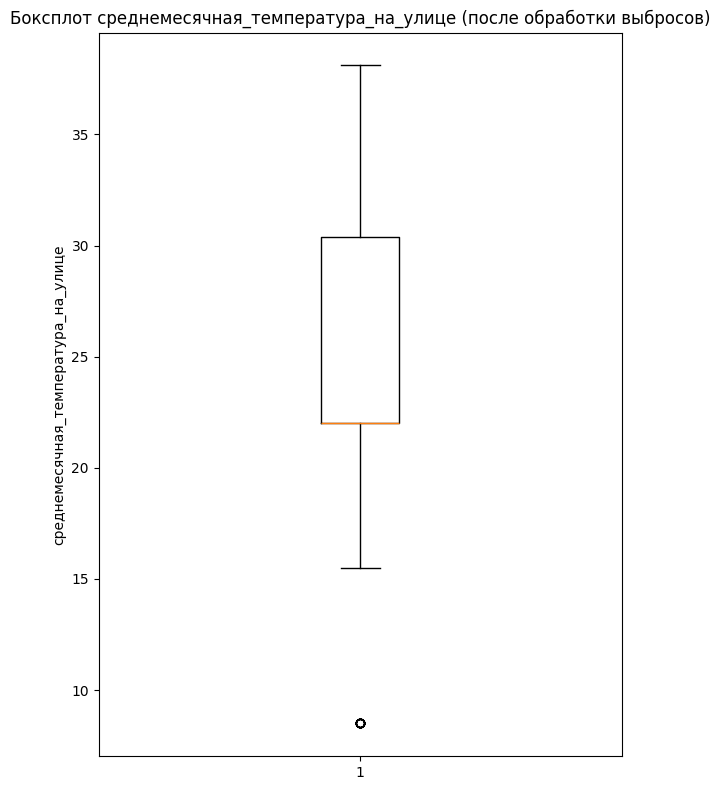

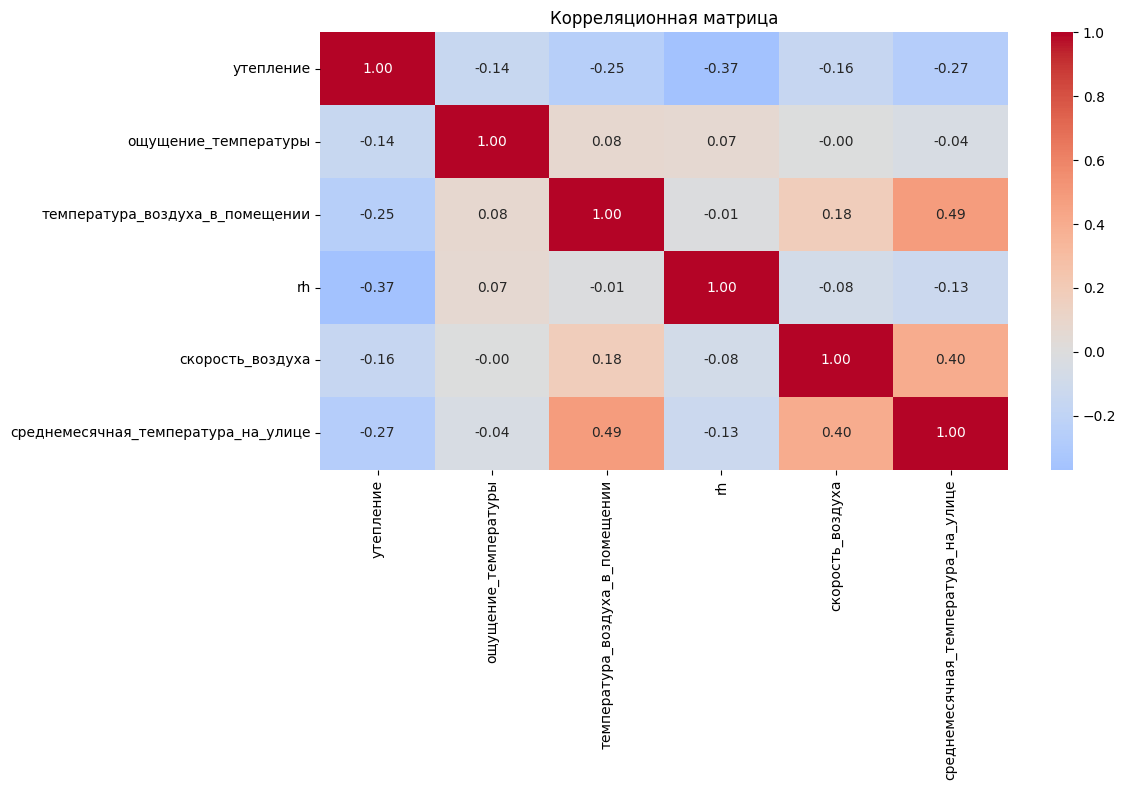

In [64]:
numeric_df = df[["утепление", "ощущение_температуры", "температура_воздуха_в_помещении", "rh", "скорость_воздуха", "среднемесячная_температура_на_улице"]]
numeric_stats = numeric_df.describe()
correlation_matrix = numeric_df.corr()

try:
    numeric_cols = numeric_df.columns
    for col in numeric_cols:
        plt.figure(figsize=(8, 6))
        plt.hist(df[col], bins=30, alpha=0.7, edgecolor="black")
        plt.title(f"Распределение {col}")
        plt.xlabel(col)
        plt.ylabel("Частота")
        plt.tight_layout()
        plt.savefig(
            f"data/graphics/histograms/histogram_{col}.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.close()

    for col in numeric_cols:
        plt.figure(figsize=(6, 8))
        plt.boxplot(df[col])
        plt.title(f"Боксплот {col} (после обработки выбросов)")
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(
            f"data/graphics/boxplots/boxplot_{col}.png",
            dpi=150,
            bbox_inches="tight",
        )

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f"
    )
    plt.title("Корреляционная матрица")
    plt.tight_layout()
    plt.savefig(
        "data/graphics/correlation/correlation_heatmap.png",
        dpi=150,
        bbox_inches="tight",
    )

except Exception as e:
    pass

#### Проведение расчётов и исследований
 - Создать дополнительный категориальный столбец, который покажет количество рекламаций по каждому клиенту отдельно: мало (≤1), средне (=2), много (>2).
 - Рассчитать средний возраст респондентов по полу и стране
 - Добавить категориальный столбец, разделив респондентов на три категории по возрасту: до 44 лет - молодой возраст, 45 - 59 лет - средний возраст, 60 лет и больше - пожилой возраст.
 - Рассчитать среднюю комфортную температуру в зависимости от возрастной категории
 - Рассчитать медианное значение температуры и влажности для каждого типа охлаждения
 - Добавить столбец с процентом удовлетворенных респондентов температурой воздуха в помещении относительно всех респондентов одной страны и одного пола
 - Составить сводную таблицу, в которой данные будут сгруппированы по стране, полу, возрастной группе и подсчитаны средняя температура воздуха в помещении, на улице и средняя относительная влажность для каждой из этих групп.
 - Самостоятельно найти информацию по стандартной комфортной относительной влажности в помещениях (в нашем случае - офисы). Создать новый категориальный столбец, в котором будет показано, удовлетворяет ли зафиксированная относительная влажность стандарту или нет. Категории назначить самостоятельно.
 - Исследовать корреляцию между параметрами. Объяснить наиболее коррелирующие параметры, имеет ли это реальный смысл или просто особенность данных?

##### Дополнительный категориальный столбец по количеству рекламаций

In [65]:
df["количество_рекламаций_кат"] = "мало"
df.loc[df["количество_рекламаций"] == 2, "количество_рекламаций_кат"] = "средне"
df.loc[df["количество_рекламаций"] > 2, "количество_рекламаций_кат"] = "много"
print(df["количество_рекламаций_кат"].value_counts())

количество_рекламаций_кат
мало      474
много       7
средне      3
Name: count, dtype: int64


##### Средний возраст респондентов по полу и стране

In [66]:
groups_gender_country = df.groupby(["страна", "пол"])
average_ages = groups_gender_country["возраст"].mean()
print(average_ages)

страна     пол       
Австралия  Женский       46.348315
           Мужской       42.614679
Индия      Женский       36.590909
           Мужской       38.333333
США        Неизвестно    36.208333
Name: возраст, dtype: float64


##### Дополнительный категориальный столбец по трем возрастным группам

In [67]:
# Категоризация фактора возраст
df["возраст_кат"] = "средний возраст"
df.loc[df["возраст"] <= 44, "возраст_кат"] = "молодой"
df.loc[df["возраст"] >= 60, "возраст_кат"] = "пожилой возраст"
print(df["возраст_кат"].value_counts())

возраст_кат
средний возраст    259
молодой            213
пожилой возраст     12
Name: count, dtype: int64


##### Средняя комфортная температура в зависимости от возрастной группы

In [68]:
comfort_groups_age = df[df["ощущение_температуры_bool"] == 1].groupby("возраст_кат")
print(comfort_groups_age["температура_воздуха_в_помещении"].mean())

возраст_кат
молодой            24.361582
пожилой возраст    25.400000
средний возраст    24.875000
Name: температура_воздуха_в_помещении, dtype: float64


##### Медианы температуры воздуха в помещении и относительной влажности по способу охлаждения

In [69]:
cooling_method_grouping = df.groupby("способ_охлаждения")
temp_median = cooling_method_grouping["температура_воздуха_в_помещении"].median()
humidity_median = cooling_method_grouping["rh"].median()
print(temp_median, humidity_median, sep="\n\n")

способ_охлаждения
Вентиляция           24.6
Кондиционирование    24.4
Смешанный            24.6
Name: температура_воздуха_в_помещении, dtype: float64

способ_охлаждения
Вентиляция           46.30
Кондиционирование    42.45
Смешанный            56.30
Name: rh, dtype: float64


##### Удовлетворенность температурой воздуха в помещении относительное всех респондентов одной страны и одного пола

In [70]:
df["относительная_удовлетворенность_%"] = 0.0
satisfied_percentage_by_gender_country = (groups_gender_country["ощущение_температуры_bool"].mean() * 100).round(5)
print(satisfied_percentage_by_gender_country)
for i, row in df.iterrows():
    df.loc[i, "относительная_удовлетворенность_%"] = satisfied_percentage_by_gender_country[row["страна"], row["пол"]]
print(df["относительная_удовлетворенность_%"].unique())

страна     пол       
Австралия  Женский       68.53933
           Мужской       88.07339
Индия      Женский       79.71014
           Мужской       80.00000
США        Неизвестно    75.00000
Name: ощущение_температуры_bool, dtype: float64
[75.      68.53933 88.07339 80.      79.71014]


##### Сводная таблица средней температуры в помещении, на улице и средней относительной влажности по стране, полу, возрастной группе

In [71]:
gender_country_age_groups = df.groupby(["страна", "пол", "возраст_кат"])
table = gender_country_age_groups.agg({"температура_воздуха_в_помещении": "mean",
                                       "температура_воздуха_на_улице": "mean",
                                       "rh": "mean"})
print(table)

                                      температура_воздуха_в_помещении  \
страна    пол        возраст_кат                                        
Австралия Женский    молодой                                23.840000   
                     пожилой возраст                        24.900000   
                     средний возраст                        24.112500   
          Мужской    молодой                                24.146667   
                     пожилой возраст                        24.733333   
                     средний возраст                        24.044262   
Индия     Женский    молодой                                24.913793   
                     средний возраст                        25.867500   
          Мужской    молодой                                24.629630   
                     пожилой возраст                        29.300000   
                     средний возраст                        25.723333   
США       Неизвестно молодой                       

##### Добавление категориального столбца по соответствию относительной влажности к стандарту

In [72]:
# В интернете я нашел, что лучше всего иметь относительную влажность в офисе 40%-60%
min_rh = 40
max_rh = 60
df["стандартное_rh_bool"] = 0
df.loc[(df["rh"] >= 40) & (df["rh"] <= 60), "стандартное_rh_bool"] = 1
print(df["стандартное_rh_bool"].value_counts())

стандартное_rh_bool
1    244
0    240
Name: count, dtype: int64


##### Исследование корреляции

Деление факторов по типу

In [73]:
# Деление на разные виды факторов
numeric_factors = {"возраст", "температура_воздуха_в_помещении", "температура_воздуха_на_улице",
                   "rh", "скорость_воздуха", "рост", "вес", "среднемесячная_температура_на_улице",
                   "количество_рекламаций", "относительная_удовлетворенность_%", "утепление",
                   "оценка_комфорта", "ощущение_температуры"}
nominal_factors = set(df.columns).difference(numeric_factors)
one_value_factors = set()
for i in nominal_factors:
    if df[i].dropna().unique().size == 1:
        one_value_factors.add(i)
nominal_factors = nominal_factors.difference(one_value_factors)
print(one_value_factors)
print(numeric_factors)
print(nominal_factors)

{'способ_обогрева'}
{'утепление', 'количество_рекламаций', 'rh', 'оценка_комфорта', 'рост', 'относительная_удовлетворенность_%', 'температура_воздуха_в_помещении', 'температура_воздуха_на_улице', 'ощущение_температуры', 'скорость_воздуха', 'возраст', 'среднемесячная_температура_на_улице', 'вес'}
{'режим_при_смешанном_типе_охлаждения', 'окно', 'возраст_кат', 'пол', 'климат', 'отопление', 'занавески', 'двери', 'предпочтительное_изменение_температуры', 'способ_охлаждения', 'ощущение_температуры_bool', 'город', 'страна', 'количество_рекламаций_кат', 'предпочтительное_изменение_движения_воздуха', 'вентилятор', 'год', 'ощущение_движения_воздуха_bool', 'стандартное_rh_bool', 'время_года'}


Подсчет корреляции между количественными факторами

In [74]:
# Кореляция между количественными факторами
results = []
numeric_factors = list(numeric_factors)
for i, col1 in enumerate(numeric_factors):
    for j, col2 in enumerate(numeric_factors[i + 1:]):
        nan_filter = ~(df[col1].isna() | df[col2].isna())
        factor1 = df.loc[nan_filter, col1]
        factor2 = df.loc[nan_filter, col2]
        if shapiro(factor1)[1] >= 0.05 and shapiro(factor2)[1] >= 0.05:
            corr, pvalue = pearsonr(factor1, factor2)
            results.append([col1, col2, round(float(corr), 5), round(float(pvalue), 5), "Пирсон"])
        else:
            corr, pvalue = spearmanr(factor1, factor2)
            results.append([col1, col2, round(float(corr), 5), round(float(pvalue), 5), "Спирмен"])
strong_num_corr = []
moderate_num_corr = []
for i in results:
    if i[3] < 0.05 and ((i[2] > 0.7) or (i[2] < -0.7)):
        strong_num_corr.append(i)
    elif i[3] < 0.05 and ((i[2] > 0.5) or (i[2] < -0.5)):
        moderate_num_corr.append(i)
print(strong_num_corr)
print()
print(moderate_num_corr)
print()

[['температура_воздуха_в_помещении', 'температура_воздуха_на_улице', 0.70804, 0.0, 'Спирмен']]

[['количество_рекламаций', 'оценка_комфорта', -0.56983, 0.0, 'Спирмен'], ['рост', 'относительная_удовлетворенность_%', 0.60846, 0.0, 'Спирмен'], ['рост', 'вес', 0.64052, 0.0, 'Спирмен']]



/tmp/ipykernel_836/742691237.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  if shapiro(factor1)[1] >= 0.05 and shapiro(factor2)[1] >= 0.05:
/home/threetatwoge/pr_yandex/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_836/742691237.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pvalue = spearmanr(factor1, factor2)


 - Положительная сильная корелляция между факторами температура_воздуха_в_помещении и температура_воздуха_на_улице - это впринципе очевидно
 - Отрицательная средняя корелляция между факторами оценка_комфорта и количество_рекламаций - чем выше оценка, тем меньше жалоб
 - Положительная средняя корелляция между весом и ростом - чем выше, тем больше вес
 - Положительная средняя корелляция между факторами рост и относительная_удовлетворенность_% - скорее всего просто совпадение

Подсчет корелляции между категориальными факторами

In [75]:
results = []
nominal_factors = list(nominal_factors)
for i, col1 in enumerate(nominal_factors):
    for j, col2 in enumerate(nominal_factors[i + 1:]):
        nan_filter = ~(df[col1].isna() | df[col2].isna())
        factor1 = df.loc[nan_filter, col1]
        factor2 = df.loc[nan_filter, col2]
        confusion_matrix = pd.crosstab(factor1, factor2)
        n = min(confusion_matrix.shape) - 1
        if n == 0:
            continue
        chi2, pvalue = chi2_contingency(confusion_matrix)[:2]
        corr = round(float((chi2 / confusion_matrix.sum().sum() / n) ** 0.5), 5)
        results.append([col1, col2, corr, round(float(pvalue), 5), "Крамер"])
strong_nom_corr = []
moderate_nom_corr = []
for i in results:
    if i[3] < 0.05 and i[2] > 0.5:
        strong_nom_corr.append(i)
    elif i[3] < 0.05 and i[2] > 0.3:
        moderate_nom_corr.append(i)
print(strong_nom_corr)
print()
print(moderate_nom_corr)
print()

[['окно', 'двери', 0.61404, 0.0, 'Крамер'], ['окно', 'город', 0.50328, 0.0, 'Крамер'], ['пол', 'занавески', 0.66787, 0.0, 'Крамер'], ['пол', 'способ_охлаждения', 0.53382, 0.0, 'Крамер'], ['пол', 'город', 0.721, 0.0, 'Крамер'], ['пол', 'страна', 0.71311, 0.0, 'Крамер'], ['пол', 'год', 0.71311, 0.0, 'Крамер'], ['климат', 'город', 1.0, 0.0, 'Крамер'], ['климат', 'страна', 0.70711, 0.0, 'Крамер'], ['климат', 'год', 0.70711, 0.0, 'Крамер'], ['занавески', 'способ_охлаждения', 0.50299, 0.0, 'Крамер'], ['занавески', 'город', 0.66787, 0.0, 'Крамер'], ['занавески', 'страна', 0.66787, 0.0, 'Крамер'], ['занавески', 'вентилятор', 0.67331, 0.0, 'Крамер'], ['занавески', 'год', 0.66787, 0.0, 'Крамер'], ['двери', 'город', 0.54644, 0.0, 'Крамер'], ['предпочтительное_изменение_температуры', 'ощущение_температуры_bool', 0.51512, 0.0, 'Крамер'], ['способ_охлаждения', 'город', 0.71532, 0.0, 'Крамер'], ['способ_охлаждения', 'страна', 0.5973, 0.0, 'Крамер'], ['способ_охлаждения', 'год', 0.5973, 0.0, 'Крамер']

In [76]:
# Подсчет корреляции между различными факторами
def eta_coef(num, nom):
    in_dis = 0
    out_dis = 0
    for i in nom.unique():
        subgroup = num[nom == i]
        in_dis += sum((subgroup - subgroup.mean())**2)
        out_dis += len(subgroup) * (subgroup.mean() - num.mean())**2
    return (out_dis / (in_dis + out_dis))**0.5


strong_mixed_corr = []
moderate_mixed_corr = []
for i in numeric_factors:
    for j in nominal_factors:
        mixed_corr = float(eta_coef(df[i], df[j]))
        if mixed_corr >= 0.7 or mixed_corr <= -0.7:
            strong_mixed_corr.append([i, j, mixed_corr])
        elif mixed_corr >= 0.5 or mixed_corr <= -0.5:
            moderate_mixed_corr.append([i, j, mixed_corr])
print(strong_mixed_corr)
print(moderate_mixed_corr)
df.to_csv("processed_data.csv", sep=";", index=False)

[['утепление', 'климат', 0.721962188260392], ['утепление', 'город', 0.7399396035997216], ['количество_рекламаций', 'количество_рекламаций_кат', 0.8698506925156009], ['относительная_удовлетворенность_%', 'пол', 0.7454060839502472], ['среднемесячная_температура_на_улице', 'город', 0.8190557050291057]]
[['утепление', 'страна', 0.6161257021608023], ['утепление', 'год', 0.6161257021608023], ['утепление', 'время_года', 0.6245105986742862], ['rh', 'город', 0.6152523593027461], ['rh', 'страна', 0.5831593231546623], ['rh', 'год', 0.5831593231546623], ['температура_воздуха_в_помещении', 'климат', 0.596542866488101], ['температура_воздуха_в_помещении', 'город', 0.6338112897955451], ['среднемесячная_температура_на_улице', 'климат', 0.6894776275737112]]


### Проверка гипотез

### **Функции**
Для автоматизации процесса проверки гипотез используются следующие функции:

*   **`distribution_group`**: Проверка нормальности распределения (Тест Шапиро) для нескольких групп.
*   **`check_normality`**: Сравнение двух конкретных выборок на нормальность.
*   **`output_pvalue`**: Вывод результатов с интерпретацией `p-value` (порог значимости **0.05**).

In [77]:
def distribution_group(groups) -> None:
    for name, group in groups:
        p_value = shapiro(group)[1]
        print(f"{name}: p-value = {float(round(p_value, 5))}")
        if p_value > 0.05:
            print("✅ Нормальное распределение")
        else:
            print("❌ НЕ нормальное распределение")


def check_normality(group1, group2) -> None:
    if (shapiro(group1)[1] >= 0.05) & (shapiro(group2)[1] >= 0.05):
        print("✅ Нормальное распределение")
    else:
        print("❌ НЕ нормальное распределение")
        print(f"Группа 1 p_value:{float(round(shapiro(group1)[1], 5))}")
        print(f"Группа 2 p_value:{float(round(shapiro(group2)[1], 5))}")


def output_pvalue(p_value, name_factor: str, name_response: str) -> None:
    if p_value <= 0.05:
        print(f"✅ p-value = {float(round(p_value, 5))} < 0.05")
        print(
            f"С уровнем значимости {float(round(p_value, 5))} можно утверждать, что {name_factor} статистически значимо влияет на {name_response}"
        )
    else:
        print("❌ Значимого влияния не обнаружено")
        print(f"p-value = {float(round(p_value, 5))}")
        print("Нет оснований отвергать нулевую гипотезу.")

### **Влияет ли способ охлаждения на оценку комфорта?**

*   **Фактор:** `Способ_охлаждения` — Номинальная (3 уровня).
*   **Отклик:** `Оценка_комфорта` — Порядковая (6 уровней).


In [78]:
df_cold = df[["способ_охлаждения", "оценка_комфорта"]].dropna()
groups_cold = df_cold.groupby("способ_охлаждения")["оценка_комфорта"]
distribution_group(groups_cold)

Вентиляция: p-value = 0.0
❌ НЕ нормальное распределение
Кондиционирование: p-value = 0.0
❌ НЕ нормальное распределение
Смешанный: p-value = 0.0
❌ НЕ нормальное распределение


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **Краскела-Уоллеса**.

In [79]:
vent = df_cold[df_cold["способ_охлаждения"] == "Вентиляция"][
    "оценка_комфорта"
]
condit = df_cold[df_cold["способ_охлаждения"] == "Кондиционирование"][
    "оценка_комфорта"
]
mixed = df_cold[df_cold["способ_охлаждения"] == "Смешанный"][
    "оценка_комфорта"
]

p_cold = kruskal(vent, condit, mixed)[1]
output_pvalue(p_cold, "способ охлаждения", "оценку комфорта")

❌ Значимого влияния не обнаружено
p-value = 0.06733
Нет оснований отвергать нулевую гипотезу.


### **Влияет ли пол на оценку комфорта?**

*   **Фактор:** `Пол` — Бинарная.
*   **Отклик:** `Оценка_комфорта` — Порядковая (6 уровней).

In [80]:
df_gender = df[["пол", "оценка_комфорта"]].dropna()

group_man = df_gender[df_gender["пол"] == "Мужской"]["оценка_комфорта"]
group_women = df_gender[df_gender["пол"] == "Женский"]["оценка_комфорта"]

check_normality(group_man, group_women)


❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:3e-05


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **U-критерия Манна-Уитни**.

In [81]:
p_gender = mannwhitneyu(group_man, group_women, alternative="two-sided")[1]
output_pvalue(p_gender, "пол", "оценку комфорта")

❌ Значимого влияния не обнаружено
p-value = 0.12111
Нет оснований отвергать нулевую гипотезу.


### **Влияет ли возрастная группа на оценку комфорта?**

*   **Фактор:** `Возрастная группа` — Номинальная.
*   **Отклик:** `Оценка_комфорта` — Порядковая (6 уровней).

In [82]:
df_ages = df[["возраст_кат", "оценка_комфорта"]].dropna()
df_two_gr = df_ages[df_ages["возраст_кат"] != "пожилой возраст"]

young = df_two_gr[df_two_gr["возраст_кат"] == "молодой"]["оценка_комфорта"]
middle = df_two_gr[df_two_gr["возраст_кат"] == "средний возраст"][
    "оценка_комфорта"
]

check_normality(young, middle)

❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:0.0


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **U-критерия Манна-Уитни**.

In [83]:
p_age = mannwhitneyu(young, middle, alternative="two-sided")[1]
output_pvalue(p_age, "возрастная группа", "оценку комфорта")

✅ p-value = 0.00243 < 0.05
С уровнем значимости 0.00243 можно утверждать, что возрастная группа статистически значимо влияет на оценку комфорта


### **Взаимосвязь между количеством рекламаций и оценкой комфорта**

*   **Фактор:** `Количество_рекламаций` — Количественная.
*   **Отклик:** `Оценка_комфорта` — Порядковая (6 уровней).

In [84]:
df_report = df[["количество_рекламаций", "оценка_комфорта"]].dropna()
count_report = df_report["количество_рекламаций"]
score_comfort = df_report["оценка_комфорта"]

check_normality(count_report, score_comfort)


❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:0.0


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **корреляции Спирмена**.

In [85]:
corr, p_report = spearmanr(count_report, score_comfort)
print(
    f"Корреляция Спирмена r = {corr}"
)  # показывает умеренную отрицательную связь: чем больше рекламаций, тем ниже оценка комфорта"
output_pvalue(p_report, "количеством рекламаций", "оценку комфорта")

Корреляция Спирмена r = -0.5698346757909493
✅ p-value = 0.0 < 0.05
С уровнем значимости 0.0 можно утверждать, что количеством рекламаций статистически значимо влияет на оценку комфорта


### **Различие средней оценки комфорта в зависимости от страны**

*   **Фактор:** `Страна` (Номинальная)
*   **Отклик:** `Оценка_комфорта` (Порядковая)

In [86]:
usa = df[df["страна"] == "США"]["оценка_комфорта"]
india = df[df["страна"] == "Индия"]["оценка_комфорта"]
check_normality(usa, india)

❌ НЕ нормальное распределение
Группа 1 p_value:0.00107
Группа 2 p_value:nan


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **U-критерия Манна-Уитни**.

In [87]:
p_country = mannwhitneyu(usa, india, alternative="two-sided")[1]
output_pvalue(p_country, "страна", "оценку комфорта")

❌ Значимого влияния не обнаружено
p-value = nan
Нет оснований отвергать нулевую гипотезу.


### **Влияние разницы температур на ощущение температуры**

*   **Фактор:** `Разница_температур` (Количественная)
*   **Отклик:** `Ощущение_температуры` (Количественная)

In [88]:
df_clean = df[
    [
        "температура_воздуха_в_помещении",
        "температура_воздуха_на_улице",
        "ощущение_температуры",
    ]
].dropna()

df_clean["разница_температур"] = (
    df_clean["температура_воздуха_в_помещении"]
    - df_clean["температура_воздуха_на_улице"]
)

check_normality(
    df_clean["разница_температур"], df_clean["ощущение_температуры"]
)

❌ НЕ нормальное распределение
Группа 1 p_value:0.00148
Группа 2 p_value:0.00067


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **корреляции Спирмена**.

In [89]:
corr, p_temperature = spearmanr(
    df_clean["разница_температур"], df_clean["ощущение_температуры"]
)
print(f"Корреляция Спирмена r = {corr}")
output_pvalue(p_temperature, "разница температур", "ощущение температуры")

Корреляция Спирмена r = 0.042650238607751474
❌ Значимого влияния не обнаружено
p-value = 0.72204
Нет оснований отвергать нулевую гипотезу.


### **Влияет ли тип климата на ощущение температуры?**

*   **Фактор:** `Климат` (5 уровней)
*   **Отклик:** `Ощущение_температуры` (Количественная)

In [90]:
df["климат"] = df["климат"].replace(
    "Cубтроп океанич", "Cубтропический океанический"
)

df_climate = df[["климат", "ощущение_температуры"]].dropna()
groups_climate = df_climate.groupby("климат")["ощущение_температуры"]
distribution_group(groups_climate)

Cубтропический океанический: p-value = 0.0
❌ НЕ нормальное распределение
Влажный субтропический муссонный: p-value = 0.0
❌ НЕ нормальное распределение
Жаркий полузасушливый: p-value = 2e-05
❌ НЕ нормальное распределение
Субтропическое высокогорье: p-value = 0.0
❌ НЕ нормальное распределение
Тропическая влажная саванна: p-value = 0.0
❌ НЕ нормальное распределение


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **Краскела-Уоллеса**.

In [91]:
subtropical_ocean = df_climate[
    df_climate["климат"] == "Cубтропический океанический"
]["ощущение_температуры"]

tropical_savanna = df_climate[
    df_climate["климат"] == "Тропическая влажная саванна"
]["ощущение_температуры"]

hot = df_climate[df_climate["климат"] == "Жаркий полузасушливый"][
    "ощущение_температуры"
]

water_subtropical = df_climate[
    df_climate["климат"] == "Влажный субтропический муссонный"
]["ощущение_температуры"]

subtropical_highland = df_climate[
    df_climate["климат"] == "Субтропическое высокогорье"
]["ощущение_температуры"]

p_climate = kruskal(
    subtropical_ocean,
    tropical_savanna,
    hot,
    water_subtropical,
    subtropical_highland,
)[1]
output_pvalue(p_climate, "тип климата", "ощущение температуры")

✅ p-value = 0.01877 < 0.05
С уровнем значимости 0.01877 можно утверждать, что тип климата статистически значимо влияет на ощущение температуры


### **Влияет ли ощущение температуры на оценку комфорта?**

*   **Фактор:** `Ощущение_температуры` (Количественная)
*   **Отклик:** `Оценка_комфорта` (Порядковая)

In [92]:
df_temp_comfort = df[["ощущение_температуры", "оценка_комфорта"]].dropna()

check_normality(
    df_temp_comfort["ощущение_температуры"],
    df_temp_comfort["оценка_комфорта"],
)

❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:0.0


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **корреляции Спирмена**.
Python



In [93]:
orr, p_temp_comfort = spearmanr(
    df_temp_comfort["ощущение_температуры"],
    df_temp_comfort["оценка_комфорта"],
)

print(f"Корреляция Спирмена r = {round(corr, 4)}")
output_pvalue(p_temp_comfort, "ощущение температуры", "оценку комфорта")

Корреляция Спирмена r = 0.0427
✅ p-value = 0.00204 < 0.05
С уровнем значимости 0.00204 можно утверждать, что ощущение температуры статистически значимо влияет на оценку комфорта


### **Влияет ли относительная влажность на оценку комфорта?**

*   **Фактор:** `RH` (Количественная)
*   **Отклик:** `Оценка_комфорта` (Порядковая)

In [94]:
df_rh = df[["rh", "оценка_комфорта"]].dropna()

check_normality(df_rh["rh"], df_rh["оценка_комфорта"])


❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:0.0


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **корреляции Спирмена**.

In [95]:
corr, p_rh = spearmanr(df_rh["rh"], df_rh["оценка_комфорта"])
print(f"Корреляция Спирмена r = {round(corr, 4)}")
output_pvalue(p_rh, "относительная влажность", "оценку комфорта")

Корреляция Спирмена r = 0.1597
✅ p-value = 0.01916 < 0.05
С уровнем значимости 0.01916 можно утверждать, что относительная влажность статистически значимо влияет на оценку комфорта


### **Влияет ли скорость воздуха на приемлемость движения воздуха?**

*   **Фактор:** `Скорость_воздуха` (Количественная)
*   **Отклик:** `Приемлемость_движения_воздуха` (Бинарная)

In [96]:
df_air = df[["скорость_воздуха", "ощущение_движения_воздуха_bool"]].dropna()

acceptable = df_air[df_air["ощущение_движения_воздуха_bool"] == 1][
    "скорость_воздуха"
]
not_acceptable = df_air[df_air["ощущение_движения_воздуха_bool"] == 0][
    "скорость_воздуха"
]

check_normality(acceptable, not_acceptable)


❌ НЕ нормальное распределение
Группа 1 p_value:0.0
Группа 2 p_value:0.00015


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **U-критерия Манна-Уитни**.

In [97]:
p_air = mannwhitneyu(acceptable, not_acceptable, alternative="two-sided")[1]
output_pvalue(p_air, "скорость воздуха", "приемлемость движения воздуха")

❌ Значимого влияния не обнаружено
p-value = 0.05994
Нет оснований отвергать нулевую гипотезу.


### **Влияет ли способ охлаждения на приемлемость движения воздуха?**

*   **Фактор:** `Способ_охлаждения` (3 уровня)
*   **Отклик:** `Приемлемость_движения_воздуха` (Бинарная)

In [98]:
df_air = df[["способ_охлаждения", "ощущение_движения_воздуха_bool"]].dropna()

groups_air = df_air.groupby("способ_охлаждения")[
    "ощущение_движения_воздуха_bool"
]
distribution_group(groups_air)

Вентиляция: p-value = 1.0
✅ Нормальное распределение
Кондиционирование: p-value = 1.0
✅ Нормальное распределение
Смешанный: p-value = 0.0
❌ НЕ нормальное распределение


/home/threetatwoge/pr_yandex/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


**Результат проверки нормальности:** Тест Шапиро-Уилка показал ненормальное распределение во всех группах (p-value < 0.05). Проверка гипотезы производится методом **Краскела-Уоллеса**.

In [99]:
groups_air = df_air.groupby("способ_охлаждения")[
    "ощущение_движения_воздуха_bool"
]
distribution_group(groups_air)

gr_went = df_air[df_air["способ_охлаждения"] == "Вентиляция"][
    "ощущение_движения_воздуха_bool"
]
gr_condit = df_air[df_air["способ_охлаждения"] == "Кондиционирование"][
    "ощущение_движения_воздуха_bool"
]
gr_mix = df_air[df_air["способ_охлаждения"] == "Смешанный"][
    "ощущение_движения_воздуха_bool"
]

p_air = kruskal(gr_went, gr_condit, gr_mix)[1]
output_pvalue(p_air, "способ охлаждения", "приемлемость движения воздуха")

Вентиляция: p-value = 1.0
✅ Нормальное распределение
Кондиционирование: p-value = 1.0
✅ Нормальное распределение
Смешанный: p-value = 0.0
❌ НЕ нормальное распределение
✅ p-value = 1e-05 < 0.05
С уровнем значимости 1e-05 можно утверждать, что способ охлаждения статистически значимо влияет на приемлемость движения воздуха


### Регрессионное моделирование

In [100]:
def get_ohe(train, categ):
    '''
    Функция для ohe_категоризации необходимых столбцов и последующего объединения с количественными столбцами
    '''
    temp_df = pd.DataFrame(data=ohe.transform(train[categ]), columns=ohe.get_feature_names_out())
    data = pd.concat([train.reset_index(drop=True), temp_df], axis=1)
    data = data.drop(columns=categ, axis=1)
    return data

ohe = OneHotEncoder(sparse_output=False, drop='first')

In [101]:
selected_columns = [
    'температура_воздуха_в_помещении',
    'температура_воздуха_на_улице',
    'среднемесячная_температура_на_улице',
    'rh',
    'скорость_воздуха',
    'способ_охлаждения',
    'климат',
    "среднемесячная_температура_на_улице"
]

data = df[selected_columns].dropna()

target = data['температура_воздуха_в_помещении']
features = data.drop(columns=['температура_воздуха_в_помещении'])

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.15, random_state=42)

categ_cols = ['способ_охлаждения', 'климат' ]
ohe.fit(x_train[categ_cols])

x_train = get_ohe(x_train, categ_cols)
x_test = get_ohe(x_test, categ_cols)


ValueError: Cannot specify both 'axis' and 'index'/'columns'

### **Оценка качества модели**

Для анализа точности прогноза температуры используются три ключевые метрики:

*   **R2 (Коэффициент детерминации):** Показывает, какой % изменений температуры объясняет модель. Высокое значение подтверждает, что модель понимает и может предсказать логику процесса.
*   **MAE (Средняя ошибка):** Показывает среднюю погрешность прогноза в градусах (**°C**).
*   **RMSE (Квадратичная ошибка):** Позволяет увидеть наличие крупных просчетов в прогнозе, на которые стоит обратить внимание.

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

prediction = lr.predict(x_test)

# Метрики
r2 = r2_score(y_test, prediction)
mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))

print(f'Коэффициент детерминации (R2): {round(r2, 5)}')
print(f'Средняя абсолютная ошибка (MAE): {round(mae, 2)}°C')
print(f'Среднеквадратичная ошибка (RMSE): {round(rmse, 2)}°C')

Коэффициент детерминации (R2): 0.50238
Средняя абсолютная ошибка (MAE): 0.38°C
Среднеквадратичная ошибка (RMSE): 0.48°C


In [ ]:
importance = pd.DataFrame({
    'Признак': x_train.columns,
    'Коэффициент (Влияние)': lr.coef_
}).sort_values(by='Коэффициент (Влияние)')

importance

,Признак,Коэффициент (Влияние)
3,скорость_воздуха,-2.215314
2,rh,-0.020190
1,среднемесячная_температура_на_улице,0.003560
4,среднемесячная_температура_на_улице,0.003560
0,температура_воздуха_на_улице,1.026296
